# AEMO Battery Trading Environment Test

This notebook demonstrates the new `AEMOBatteryTradingEnv` environment that incorporates real AEMO market data for battery trading simulations.

## Features
- Energy market participation (buy low, sell high)
- FCAS market participation (frequency regulation services)
- Real AEMO market data integration
- Battery degradation modeling
- Multi-objective optimization

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from AEMOBatteryEnv import create_aemo_env_from_data, AEMOBatteryTradingEnv
from aemo_data import fetch_aemo_data_bundle, AEMO_REGIONS, FCAS_SERVICES

# Set random seed for reproducibility
np.random.seed(42)

print(AEMO_REGIONS)
region = AEMO_REGIONS[0]  # Select the first region for testing

# Define date range for testing
start_date = datetime(2024, 6, 1)
end_date = datetime(2024, 6, 7)  # One week of data

['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']


## 1. Create Environment with AEMO Data

We'll fetch a week of AEMO data and create an environment.

In [ ]:
# Create environment (this will fetch and preprocess data)
env = create_aemo_env_from_data(
    start_date=start_date,
    end_date=end_date,
    region=region,
    battery_capacity=10.0,  # 10 MWh battery
    max_battery_flow=5.0,   # 5 MW max charge/discharge
    init_battery_level=5.0, # Start at 50% SOC
    max_step=288,           # ~1 day of 30-min steps
    step_duration=0.5,      # 30 minutes
    battery_life_cost=1_000_000.0,  # $1M grid-scale battery
    action_mode='simple'    # Simple energy-only mode first
)

print(f"Environment created successfully!")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Fetching AEMO data for NSW1 from 2024-06-01 to 2024-06-07...
Fetching AEMO data bundle for NSW1 from 2024-06-01 to 2024-06-07...
Fetching dispatch price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Fetched 1728 price records
Fetching FCAS RAISEREG price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS LOWERREG price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS RAISE6SEC price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS LOWER6SEC price data for NSW1 from 2024-06-01 

## 2. Test Environment with Random Policy

Let's run a simple episode with random actions to verify the environment works.

In [3]:
# Reset environment
obs, info = env.reset(seed=42)

print(f"Initial observation shape: {obs.shape}")
print(f"Initial observation (first 10 elements): {obs[:10]}")

# Run episode with random actions
rewards = []
soc_history = [env.battery_soc]
actions_history = []

for step in range(100):  # Run 100 steps (~50 hours)
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    rewards.append(reward)
    soc_history.append(info['battery_soc'])
    actions_history.append(action[0] if isinstance(action, np.ndarray) else action)
    
    if terminated or truncated:
        print(f"Episode terminated at step {step}")
        break

print(f"\nEpisode completed!")
print(f"Total steps: {len(rewards)}")
print(f"Total reward: {sum(rewards):.2f}")
print(f"Average reward: {np.mean(rewards):.4f}")
print(f"Final SOC: {soc_history[-1]:.2f} MWh ({soc_history[-1]/env.battery_capacity*100:.1f}%)")

Initial observation shape: (18,)
Initial observation (first 10 elements): [ 0.         1.        -0.7818315  0.6234898  0.         0.450127
  0.4682555  0.0521082  0.01986    0.02668  ]

Episode completed!
Total steps: 100
Total reward: -2.06
Average reward: -0.0206
Final SOC: 8.78 MWh (87.8%)


## 3. Visualize Episode Results

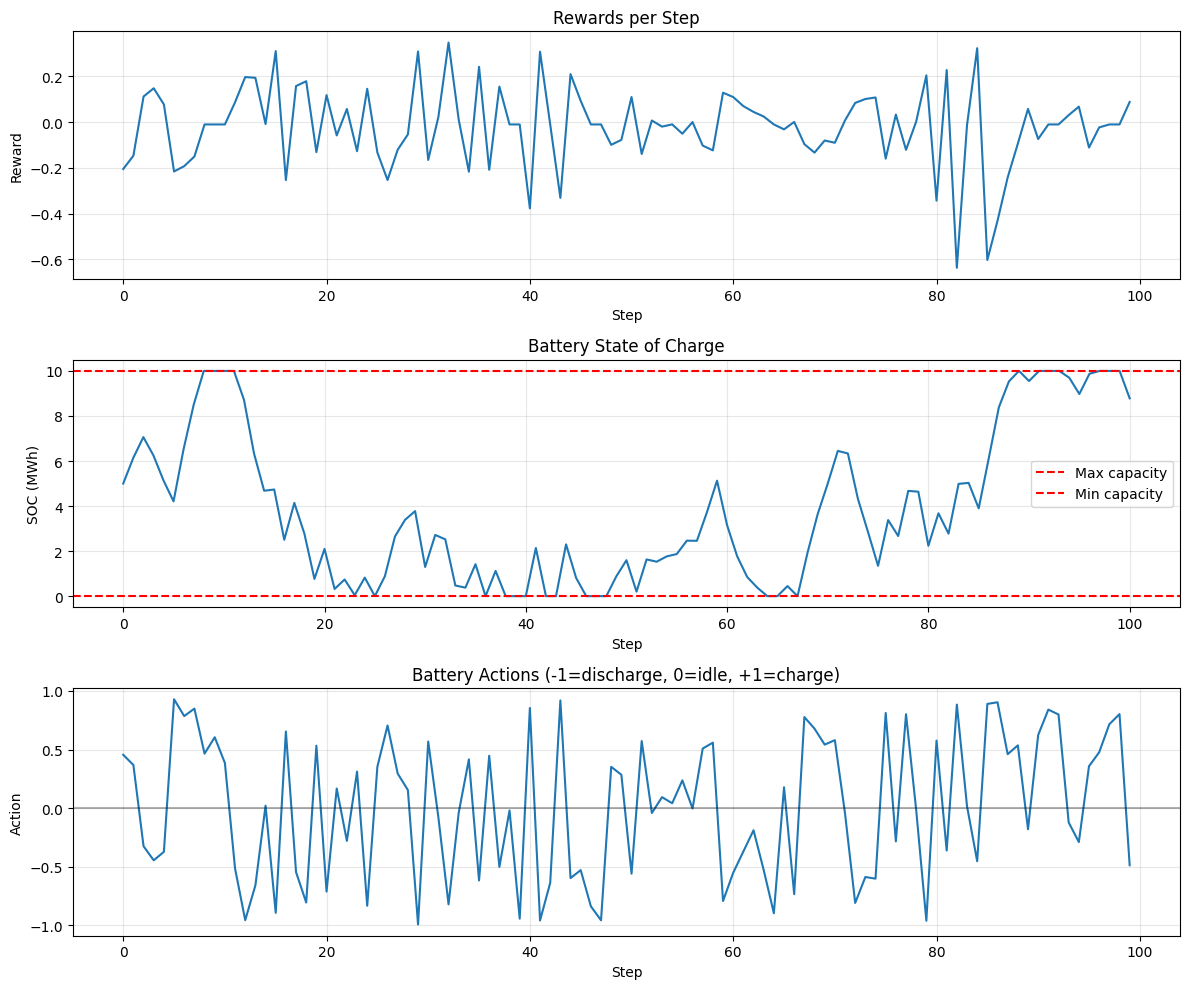

Visualization saved as 'test_aemo_env_results.png'


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot rewards
axes[0].plot(rewards)
axes[0].set_title('Rewards per Step')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].grid(True, alpha=0.3)

# Plot SOC
axes[1].plot(soc_history)
axes[1].axhline(y=env.battery_capacity, color='r', linestyle='--', label='Max capacity')
axes[1].axhline(y=0, color='r', linestyle='--', label='Min capacity')
axes[1].set_title('Battery State of Charge')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('SOC (MWh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot actions
axes[2].plot(actions_history)
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2].set_title('Battery Actions (-1=discharge, 0=idle, +1=charge)')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Action')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_aemo_env_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved as 'test_aemo_env_results.png'")

## 4. Test Rule-Based Strategy

Let's test a simple rule-based strategy:
- Charge when price is low (< 40th percentile)
- Discharge when price is high (> 60th percentile)
- Idle otherwise

In [5]:
def simple_arbitrage_policy(obs, price_low_threshold=0.4, price_high_threshold=0.6):
    """
    Simple price arbitrage policy.
    
    Args:
        obs: Environment observation
        price_low_threshold: Normalized price threshold for charging
        price_high_threshold: Normalized price threshold for discharging
    
    Returns:
        action: Battery action
    """
    # Extract normalized RRP (index 5 in observation)
    price_normalized = obs[5]
    
    # Extract battery SOC (last element)
    soc_normalized = obs[-1]
    
    # Simple strategy
    if price_normalized < price_low_threshold and soc_normalized < 0.9:
        # Low price, charge if not too full
        action = 0.8  # Charge at 80% of max rate
    elif price_normalized > price_high_threshold and soc_normalized > 0.1:
        # High price, discharge if not too empty
        action = -0.8  # Discharge at 80% of max rate
    else:
        # Idle
        action = 0.0
    
    return np.array([action])

# Run episode with rule-based policy
obs, info = env.reset(seed=42)

rb_rewards = []
rb_soc_history = [env.battery_soc]
rb_actions_history = []

for step in range(288):  # Full day
    action = simple_arbitrage_policy(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    
    rb_rewards.append(reward)
    rb_soc_history.append(info['battery_soc'])
    rb_actions_history.append(action[0])
    
    if terminated or truncated:
        break

print(f"Rule-based policy results:")
print(f"Total steps: {len(rb_rewards)}")
print(f"Total reward: {sum(rb_rewards):.2f}")
print(f"Average reward: {np.mean(rb_rewards):.4f}")
print(f"Final SOC: {rb_soc_history[-1]:.2f} MWh")

Rule-based policy results:
Total steps: 288
Total reward: 3.78
Average reward: 0.0131
Final SOC: 9.00 MWh


## 5. Compare Random vs Rule-Based Policy

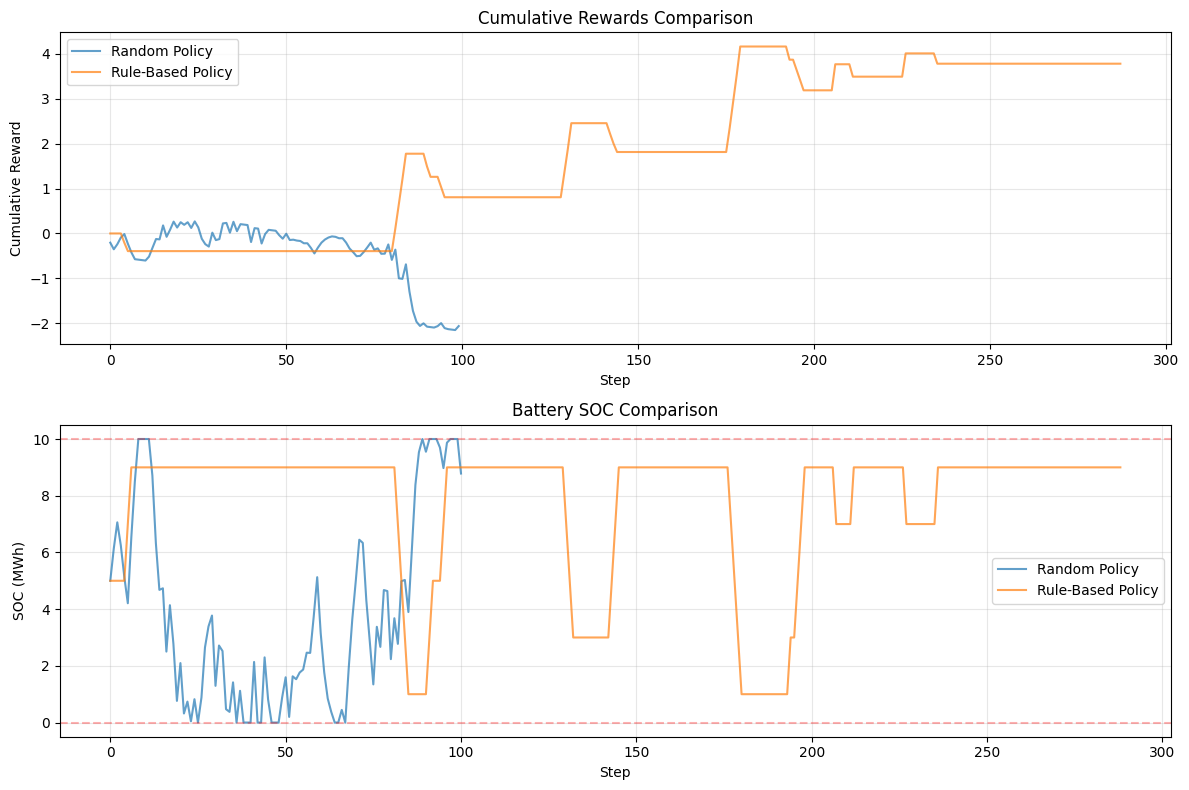


Performance Comparison:
Random policy total reward: -2.06
Rule-based policy total reward: 3.78
Improvement: 283.3%


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Compare cumulative rewards
axes[0].plot(np.cumsum(rewards[:len(rb_rewards)]), label='Random Policy', alpha=0.7)
axes[0].plot(np.cumsum(rb_rewards), label='Rule-Based Policy', alpha=0.7)
axes[0].set_title('Cumulative Rewards Comparison')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cumulative Reward')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Compare SOC trajectories
axes[1].plot(soc_history[:len(rb_soc_history)], label='Random Policy', alpha=0.7)
axes[1].plot(rb_soc_history, label='Rule-Based Policy', alpha=0.7)
axes[1].axhline(y=env.battery_capacity, color='r', linestyle='--', alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
axes[1].set_title('Battery SOC Comparison')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('SOC (MWh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPerformance Comparison:")
print(f"Random policy total reward: {sum(rewards[:len(rb_rewards)]):.2f}")
print(f"Rule-based policy total reward: {sum(rb_rewards):.2f}")
improvement = (sum(rb_rewards) - sum(rewards[:len(rb_rewards)])) / abs(sum(rewards[:len(rb_rewards)])) * 100
print(f"Improvement: {improvement:.1f}%")

## 6. Test Multi-Market Mode (Energy + FCAS)

Now let's test the multi-market mode where the battery can participate in both energy and FCAS markets.

In [2]:
# Create multi-market environment
env_mm = create_aemo_env_from_data(
    start_date=start_date,
    end_date=end_date,
    region=region,
    battery_capacity=10.0,
    max_battery_flow=5.0,
    init_battery_level=5.0,
    max_step=288,
    step_duration=0.5,
    battery_life_cost=1_000_000.0,
    action_mode='multi_market'  # Enable FCAS trading
)

print(f"Multi-market environment created!")
print(f"Action space: {env_mm.action_space}")
print(f"Action space shape: {env_mm.action_space.shape}")

Fetching AEMO data for NSW1 from 2024-06-01 to 2024-06-07...
Fetching AEMO data bundle for NSW1 from 2024-06-01 to 2024-06-07...
Fetching dispatch price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Fetched 1728 price records
Fetching FCAS RAISEREG price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS LOWERREG price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS RAISE6SEC price data for NSW1 from 2024-06-01 to 2024-06-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS LOWER6SEC price data for NSW1 from 2024-06-01 

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [8]:
# Run episode with multi-market random policy
obs, info = env_mm.reset(seed=42)

mm_rewards = []
mm_soc_history = [env_mm.battery_soc]
mm_energy_actions = []
mm_fcas_raise = []
mm_fcas_lower = []

for step in range(100):
    action = env_mm.action_space.sample()
    obs, reward, terminated, truncated, info = env_mm.step(action)
    
    mm_rewards.append(reward)
    mm_soc_history.append(info['battery_soc'])
    mm_energy_actions.append(action[0])
    mm_fcas_raise.append(action[1])
    mm_fcas_lower.append(action[2])
    
    if terminated or truncated:
        break

print(f"Multi-market episode results:")
print(f"Total steps: {len(mm_rewards)}")
print(f"Total reward: {sum(mm_rewards):.2f}")
print(f"Average reward: {np.mean(mm_rewards):.4f}")

Multi-market episode results:
Total steps: 100
Total reward: 0.69
Average reward: 0.0069


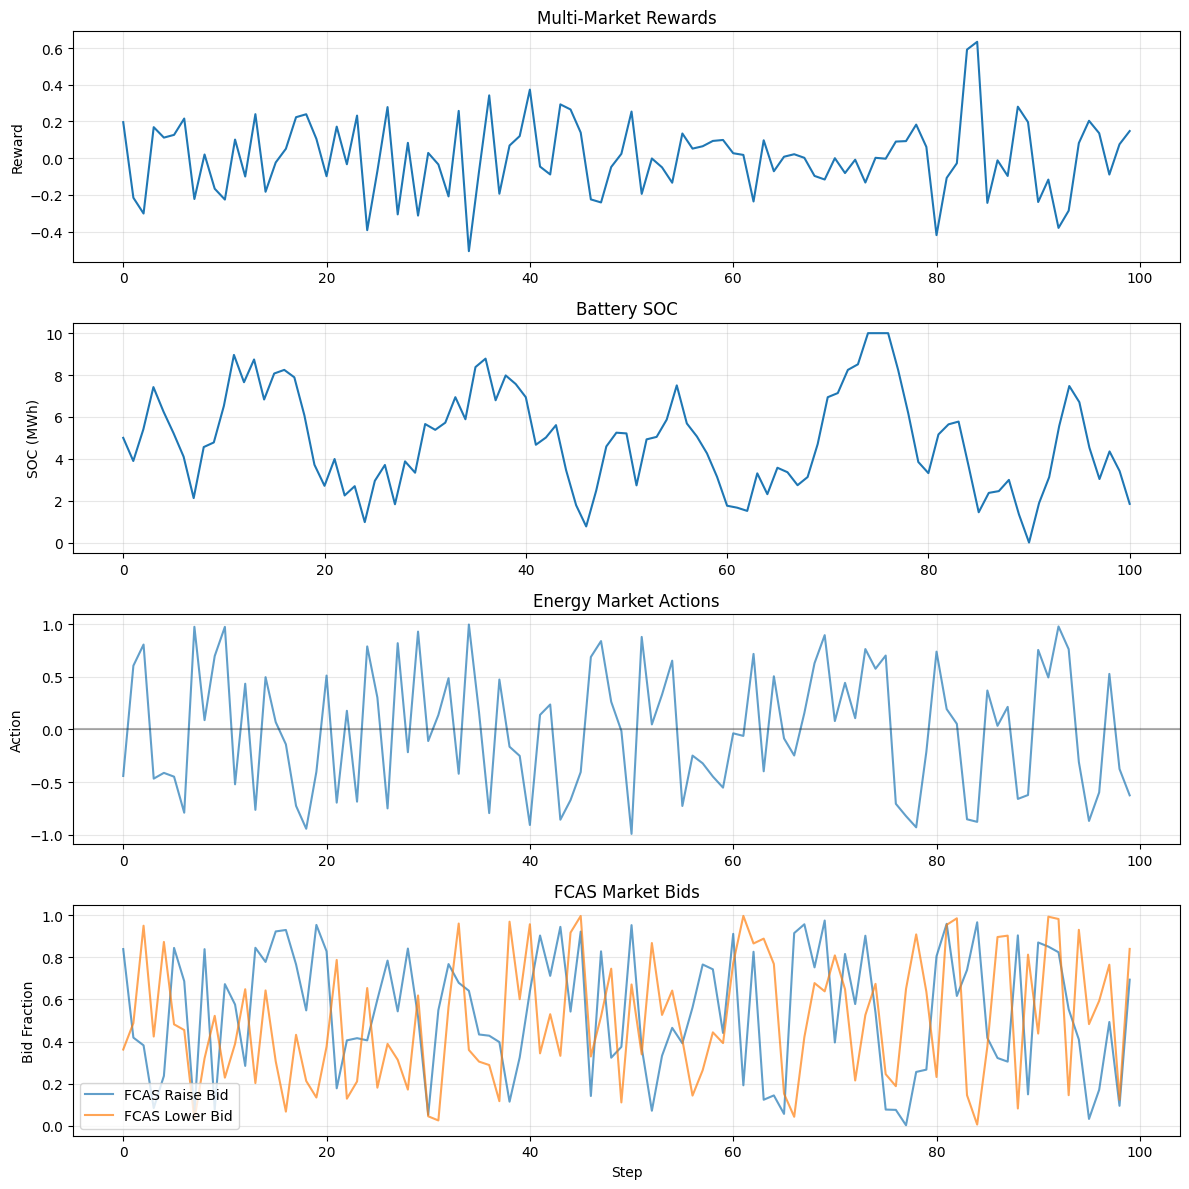

In [9]:
# Visualize multi-market actions
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

axes[0].plot(mm_rewards)
axes[0].set_title('Multi-Market Rewards')
axes[0].set_ylabel('Reward')
axes[0].grid(True, alpha=0.3)

axes[1].plot(mm_soc_history)
axes[1].set_title('Battery SOC')
axes[1].set_ylabel('SOC (MWh)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(mm_energy_actions, label='Energy dispatch', alpha=0.7)
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2].set_title('Energy Market Actions')
axes[2].set_ylabel('Action')
axes[2].grid(True, alpha=0.3)

axes[3].plot(mm_fcas_raise, label='FCAS Raise Bid', alpha=0.7)
axes[3].plot(mm_fcas_lower, label='FCAS Lower Bid', alpha=0.7)
axes[3].set_title('FCAS Market Bids')
axes[3].set_xlabel('Step')
axes[3].set_ylabel('Bid Fraction')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_market_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Test AEMOAgent Wrapper

The `AEMOAgent` class in `src/decision.py` provides a unified interface for various algorithms (Rule, RL, DT, and Dispatch Replay). Here we test the `rule` algorithm using the automated `run_episode` method which handles the internal tracking and logging.

In [3]:
from decision import AEMOAgent

# Initialize agent with the multi-market environment
# The AEMOAgent class wraps the logic we tested manually above into a reusable class
agent = AEMOAgent(env_mm, algorithm='rule')

# Run an automated episode using the agent's run_episode method
# This method handles the step loop and data collection automatically
episode_df, incident_df = agent.run_episode(display_progress=True)

print(f"\nAEMOAgent ('rule') episode completed!")
print(f"Captured {len(episode_df)} steps of simulation data.")

# Results analysis
if 'reward' in episode_df.columns:
    total_reward = episode_df['reward'].sum()
    print(f"Total Cumulative Reward: {total_reward:.2f}")

# Display the first few rows of the episode logs
episode_df.head()

Sim Complete

AEMOAgent ('rule') episode completed!
Captured 288 steps of simulation data.
Total Cumulative Reward: 0.07


step,norm_observation,raw_observation,action,reward,info
i64,list[f64],list[f64],list[f32],f64,struct[12]
0,"[0.0, 1.0, … 0.5]","[0.0, 1.0, … 5.0]","[-0.595033, 0.0, 0.0]",0.238127,"{3.512418,-2.975164,170.076206,253.002333,0.0,0.0,0.0,-1.487582,14.875822,253.002333,14.875822,1}"
1,"[0.130526, 0.991445, … 0.351242]","[0.130526, 0.991445, … 3.512418]","[-0.601383, 0.0, 0.0]",0.20985,"{2.008961,-3.006913,149.578343,224.88456,0.0,0.0,0.0,-1.503457,15.034567,477.886893,29.910389,2}"
2,"[0.258819, 0.965926, … 0.200896]","[0.258819, 0.965926, … 2.008961]","[-0.593523, 0.0, 0.0]",0.195315,"{0.525153,-2.967615,148.37012,220.152728,0.0,0.0,0.0,-1.483808,14.838077,698.039621,44.748466,3}"
3,"[0.382683, 0.92388, … 0.052515]","[0.382683, 0.92388, … 0.525153]","[0.51523, 0.0, 0.0]",-0.19779,"{1.813229,2.576151,143.554548,-184.909132,0.0,0.0,0.0,1.288076,12.880757,513.130489,57.629223,4}"
4,"[0.5, 0.866025, … 0.181323]","[0.5, 0.866025, … 1.813229]","[-0.002342, 0.0, 0.0]",0.000489,"{1.807375,-0.011708,93.570248,0.547745,0.0,0.0,0.0,-0.005854,0.058538,513.678234,57.687762,5}"


## Summary

This notebook demonstrated:

1. **Environment Creation**: Created AEMO environment with real market data
2. **Random Policy**: Tested environment with random actions
3. **Rule-Based Policy**: Implemented simple price arbitrage strategy
4. **Policy Comparison**: Compared random vs rule-based performance
5. **Multi-Market Mode**: Tested energy + FCAS participation

### Next Steps

- Train RL agents (PPO, SAC, Decision Transformer) on this environment
- Implement more sophisticated rule-based baselines
- Add price forecasting to improve decision-making
- Experiment with different battery sizes and configurations
- Backtest trained agents on held-out historical periods
- Analyze FCAS revenue contribution vs energy arbitrage